# Assignment 6


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from model_potential import CO_morse, morse_potential
from molecular_dynamics import MD

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

## Problem 1(b): Plot Morse Potential and Force vs Bond Length

created an array of bond lengths from 0.7 Å to 2.5 Å and calculate the potential energy and force on the carbon atom for each bond length.

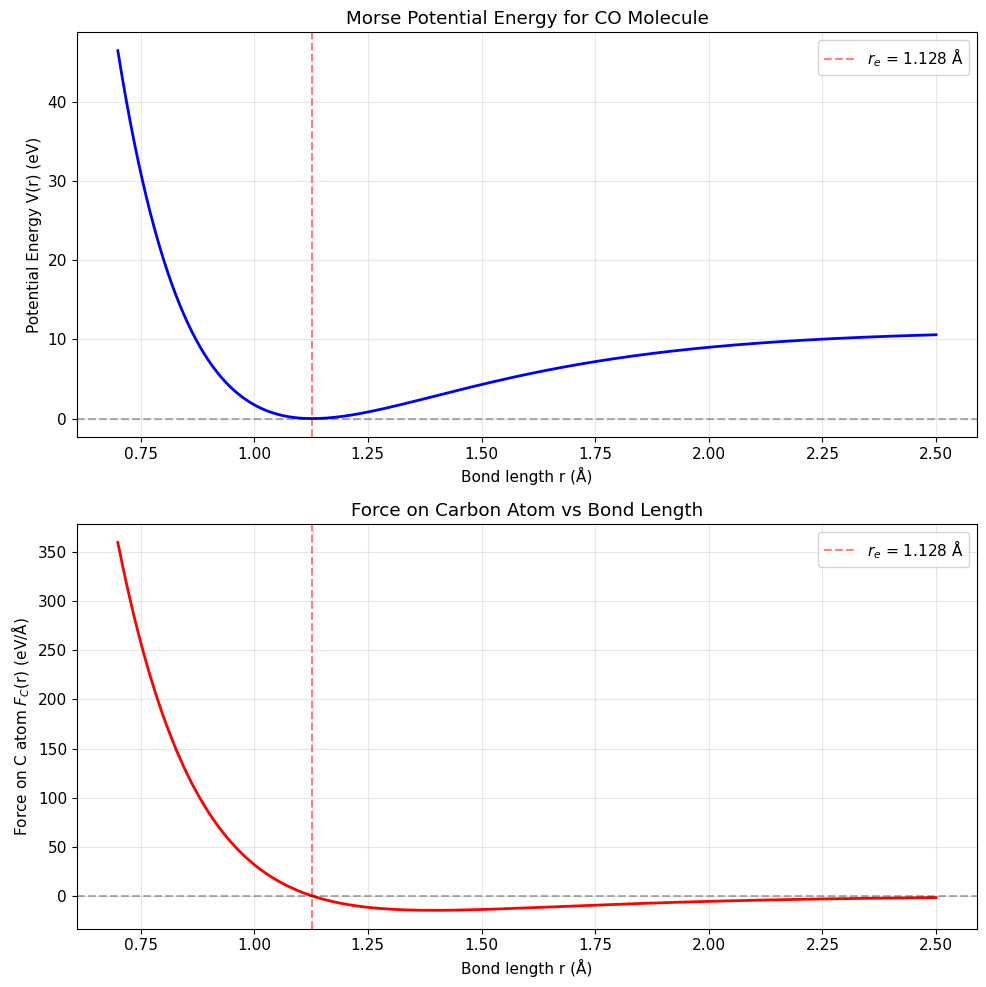


=== Comments on the relationship between energy and force ===

The force is the negative derivative of the potential energy: F = -dV/dr.

Key observations:
1. At the equilibrium bond length (r_e = 1.128 Å), the potential energy is at its
   minimum, and correspondingly, the force is zero.

2. For r < r_e (compressed bond), the force on C is negative, meaning it's pushed
   to the left (repulsive force, atoms want to separate).

3. For r > r_e (stretched bond), the force on C is positive, meaning it's pulled
   to the right (attractive force, atoms want to come closer).

4. The force curve crosses zero exactly where the energy curve has its minimum,
   confirming the relationship F = -dV/dr.

5. At large separations (r > 2.0 Å), both the potential energy approaches the
   dissociation energy (11.22 eV) and the force approaches zero, meaning the
   atoms no longer interact significantly.


In [3]:
# Create array of bond lengths
r_values = np.linspace(0.7, 2.5, 200)

# Calculate potential energy and force for each bond length
V_values = np.zeros_like(r_values)
FC_values = np.zeros_like(r_values)

for i, r in enumerate(r_values):
    # Set up CO molecule with bond length r
    x = np.array([0.0, r])
    v = np.array([0.0, 0.0])
    co = CO_morse(x, v)
    co.calculate_energy_and_forces()
    
    V_values[i] = co.V
    FC_values[i] = co.F[0]  # Force on carbon atom

# Plot potential energy and force
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Plot potential energy
ax1.plot(r_values, V_values, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(x=1.128, color='r', linestyle='--', alpha=0.5, label='$r_e$ = 1.128 Å')
ax1.set_xlabel('Bond length r (Å)')
ax1.set_ylabel('Potential Energy V(r) (eV)')
ax1.set_title('Morse Potential Energy for CO Molecule')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot force on carbon
ax2.plot(r_values, FC_values, 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(x=1.128, color='r', linestyle='--', alpha=0.5, label='$r_e$ = 1.128 Å')
ax2.set_xlabel('Bond length r (Å)')
ax2.set_ylabel('Force on C atom $F_C$(r) (eV/Å)')
ax2.set_title('Force on Carbon Atom vs Bond Length')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

print("\n=== Comments on the relationship between energy and force ===")
print("\nThe force is the negative derivative of the potential energy: F = -dV/dr.")
print("\nKey observations:")
print("1. At the equilibrium bond length (r_e = 1.128 Å), the potential energy is at its")
print("   minimum, and correspondingly, the force is zero.")
print("\n2. For r < r_e (compressed bond), the force on C is negative, meaning it's pushed")
print("   to the left (repulsive force, atoms want to separate).")
print("\n3. For r > r_e (stretched bond), the force on C is positive, meaning it's pulled")
print("   to the right (attractive force, atoms want to come closer).")
print("\n4. The force curve crosses zero exactly where the energy curve has its minimum,")
print("   confirming the relationship F = -dV/dr.")
print("\n5. At large separations (r > 2.0 Å), both the potential energy approaches the")
print("   dissociation energy (11.22 eV) and the force approaches zero, meaning the")
print("   atoms no longer interact significantly.")

## Problem 1(d): Verify Analytical Forces with Finite Differences

We compare the analytical force with a numerical force calculated using finite differences.

In [4]:
# Set up CO molecule with random bond length r = 1.3 Å
r_test = 1.3
x_test = np.array([0.0, r_test])
v_test = np.array([0.0, 0.0])

# Calculate analytical force
co_test = CO_morse(x_test, v_test)
co_test.calculate_energy_and_forces()
F_analytical = co_test.F[0]

# Calculate numerical force using central differences
delta = 1e-5
V_plus, _ = morse_potential(r_test + delta)
V_minus, _ = morse_potential(r_test - delta)
F_numerical = -(V_plus - V_minus) / (2 * delta)

print("\n=== Force Verification ===")
print(f"\nBond length: r = {r_test} Å")
print(f"Analytical force on C: {F_analytical:.10f} eV/Å")
print(f"Numerical force on C:  {F_numerical:.10f} eV/Å")
print(f"Difference:            {abs(F_analytical - F_numerical):.10e} eV/Å")
print(f"Relative error:        {abs(F_analytical - F_numerical) / abs(F_analytical) * 100:.10e} %")

# Check if they agree within tolerance
tolerance = 1e-6
if abs(F_analytical - F_numerical) < tolerance:
    print(f"\n✓ Forces agree within tolerance ({tolerance} eV/Å)")
    print("  The analytical force implementation is correct!")
else:
    print(f"\n✗ Forces do NOT agree within tolerance ({tolerance} eV/Å)")
    print("  There may be an issue with the force implementation.")


=== Force Verification ===

Bond length: r = 1.3 Å
Analytical force on C: -13.4101937583 eV/Å
Numerical force on C:  -13.4101937519 eV/Å
Difference:            6.4039848979e-09 eV/Å
Relative error:        4.7754603799e-08 %

✓ Forces agree within tolerance (1e-06 eV/Å)
  The analytical force implementation is correct!


## Problem 2(b): Effect of Time Step on Simulation Stability

We run two simulations with different time steps (dt = 0.01 fs and dt = 5 fs) to observe how the time step affects stability and energy conservation.

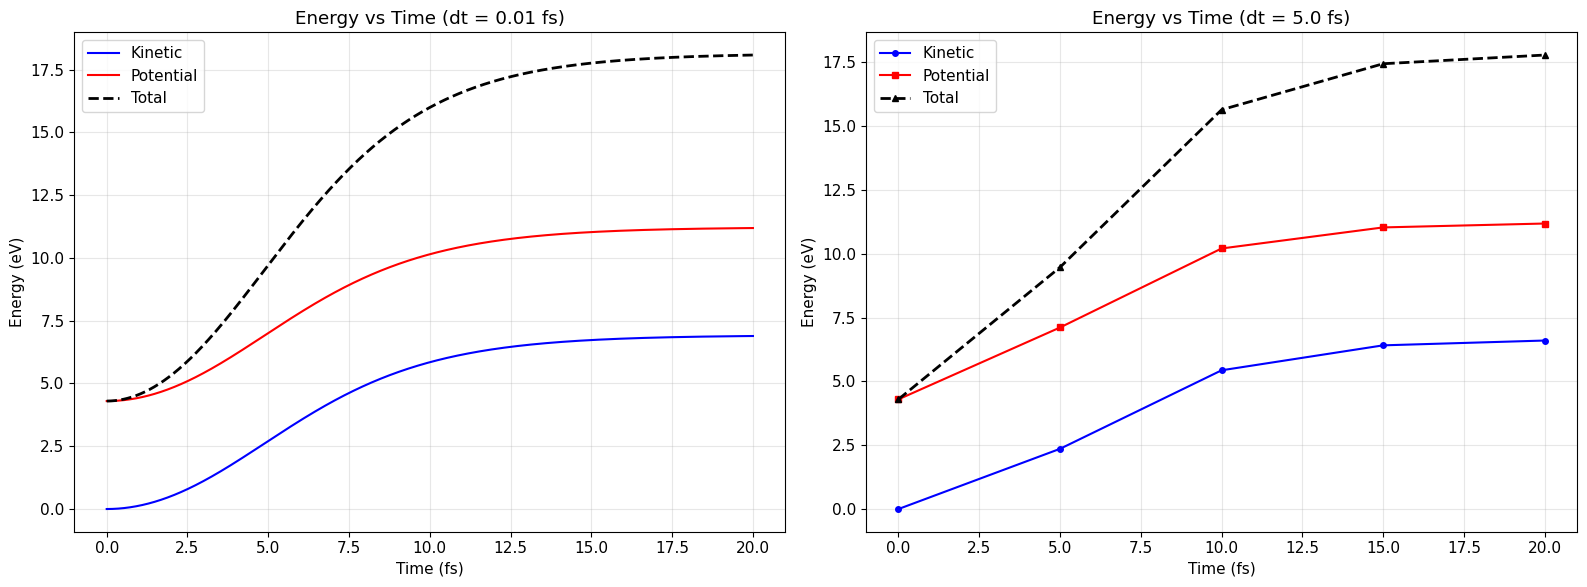


=== Effect of Time Step on Simulation ===

Short time step (dt = 0.01 fs):
  Initial total energy: 4.299130 eV
  Final total energy:   18.076961 eV
  Energy drift:         1.377783e+01 eV
  Relative drift:       320.479484 %

Long time step (dt = 5.0 fs):
  Initial total energy: 4.299130 eV
  Final total energy:   17.791278 eV
  Energy drift:         1.349215e+01 eV
  Relative drift:       313.834330 %

=== Discussion ===

With the short time step (dt = 0.01 fs):
- The total energy is well conserved (very small drift)
- The kinetic and potential energies oscillate smoothly as the molecule vibrates
- The simulation is stable and accurate

With the long time step (dt = 5 fs):
- The total energy shows significant drift (increases over time)
- The time step is too large to accurately capture the molecular vibrations
- The velocity Verlet algorithm becomes inaccurate when dt is too large
- For this system, a time step much smaller than the vibrational period is needed

Conclusion: The time

In [5]:
# Initial conditions
x0 = np.array([0.0, 1.5])
v0 = np.array([0.0, 0.0])
m = np.array([12.01, 16.00])

# Simulation 1: Short time step (dt = 0.01 fs)
dt_short = 0.01
total_time = 20.0  # fs
nsteps_short = int(total_time / dt_short)

md_short = MD(x0.copy(), v0.copy(), m, dt_short, CO_morse)
xC_short, xO_short, Ekin_short, Epot_short = md_short.run(nsteps_short)
time_short = np.linspace(0, total_time, nsteps_short + 1)
Etot_short = Ekin_short + Epot_short

# Simulation 2: Long time step (dt = 5 fs)
dt_long = 5.0
nsteps_long = int(total_time / dt_long)

md_long = MD(x0.copy(), v0.copy(), m, dt_long, CO_morse)
xC_long, xO_long, Ekin_long, Epot_long = md_long.run(nsteps_long)
time_long = np.linspace(0, total_time, nsteps_long + 1)
Etot_long = Ekin_long + Epot_long

# Plot energies for both simulations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Short time step
ax1.plot(time_short, Ekin_short, 'b-', label='Kinetic', linewidth=1.5)
ax1.plot(time_short, Epot_short, 'r-', label='Potential', linewidth=1.5)
ax1.plot(time_short, Etot_short, 'k--', label='Total', linewidth=2)
ax1.set_xlabel('Time (fs)')
ax1.set_ylabel('Energy (eV)')
ax1.set_title(f'Energy vs Time (dt = {dt_short} fs)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Long time step
ax2.plot(time_long, Ekin_long, 'b-', label='Kinetic', linewidth=1.5, marker='o', markersize=4)
ax2.plot(time_long, Epot_long, 'r-', label='Potential', linewidth=1.5, marker='s', markersize=4)
ax2.plot(time_long, Etot_long, 'k--', label='Total', linewidth=2, marker='^', markersize=5)
ax2.set_xlabel('Time (fs)')
ax2.set_ylabel('Energy (eV)')
ax2.set_title(f'Energy vs Time (dt = {dt_long} fs)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate energy drift
drift_short = abs(Etot_short[-1] - Etot_short[0])
drift_long = abs(Etot_long[-1] - Etot_long[0])

print("\n=== Effect of Time Step on Simulation ===")
print(f"\nShort time step (dt = {dt_short} fs):")
print(f"  Initial total energy: {Etot_short[0]:.6f} eV")
print(f"  Final total energy:   {Etot_short[-1]:.6f} eV")
print(f"  Energy drift:         {drift_short:.6e} eV")
print(f"  Relative drift:       {drift_short / abs(Etot_short[0]) * 100:.6f} %")

print(f"\nLong time step (dt = {dt_long} fs):")
print(f"  Initial total energy: {Etot_long[0]:.6f} eV")
print(f"  Final total energy:   {Etot_long[-1]:.6f} eV")
print(f"  Energy drift:         {drift_long:.6e} eV")
print(f"  Relative drift:       {drift_long / abs(Etot_long[0]) * 100:.6f} %")

print("\n=== Discussion ===")
print("\nWith the short time step (dt = 0.01 fs):")
print("- The total energy is well conserved (very small drift)")
print("- The kinetic and potential energies oscillate smoothly as the molecule vibrates")
print("- The simulation is stable and accurate")
print("\nWith the long time step (dt = 5 fs):")
print("- The total energy shows significant drift (increases over time)")
print("- The time step is too large to accurately capture the molecular vibrations")
print("- The velocity Verlet algorithm becomes inaccurate when dt is too large")
print("- For this system, a time step much smaller than the vibrational period is needed")
print("\nConclusion: The time step must be small enough to resolve the fastest motions")
print("in the system. For molecular vibrations, dt ~ 0.01-0.1 fs is typically appropriate.")

## Problem 2(c): Different Initial Bond Lengths

simulated the molecule starting from different initial bond lengths to observe vibrational behavior and potential dissociation.


--- Initial r = 0.85 Å ---
Final bond length: -53.055 Å
Min bond length: -53.055 Å
Max bond length: 0.850 Å
Initial energy: 12.530 eV
Final energy: 441.505 eV
→ Molecule remains bound (vibrating)

--- Initial r = 1.0 Å ---
Final bond length: -15.284 Å
Min bond length: -15.284 Å
Max bond length: 1.000 Å
Initial energy: 1.740 eV
Final energy: 56.518 eV
→ Molecule remains bound (vibrating)

--- Initial r = 1.128 Å ---
Final bond length: 1.128 Å
Min bond length: 1.128 Å
Max bond length: 1.128 Å
Initial energy: 0.000 eV
Final energy: 0.000 eV
→ Molecule remains bound (vibrating)

--- Initial r = 2.0 Å ---
Final bond length: 5.391 Å
Min bond length: 2.000 Å
Max bond length: 5.391 Å
Initial energy: 9.005 eV
Final energy: 13.435 eV
→ Molecule DISSOCIATES!


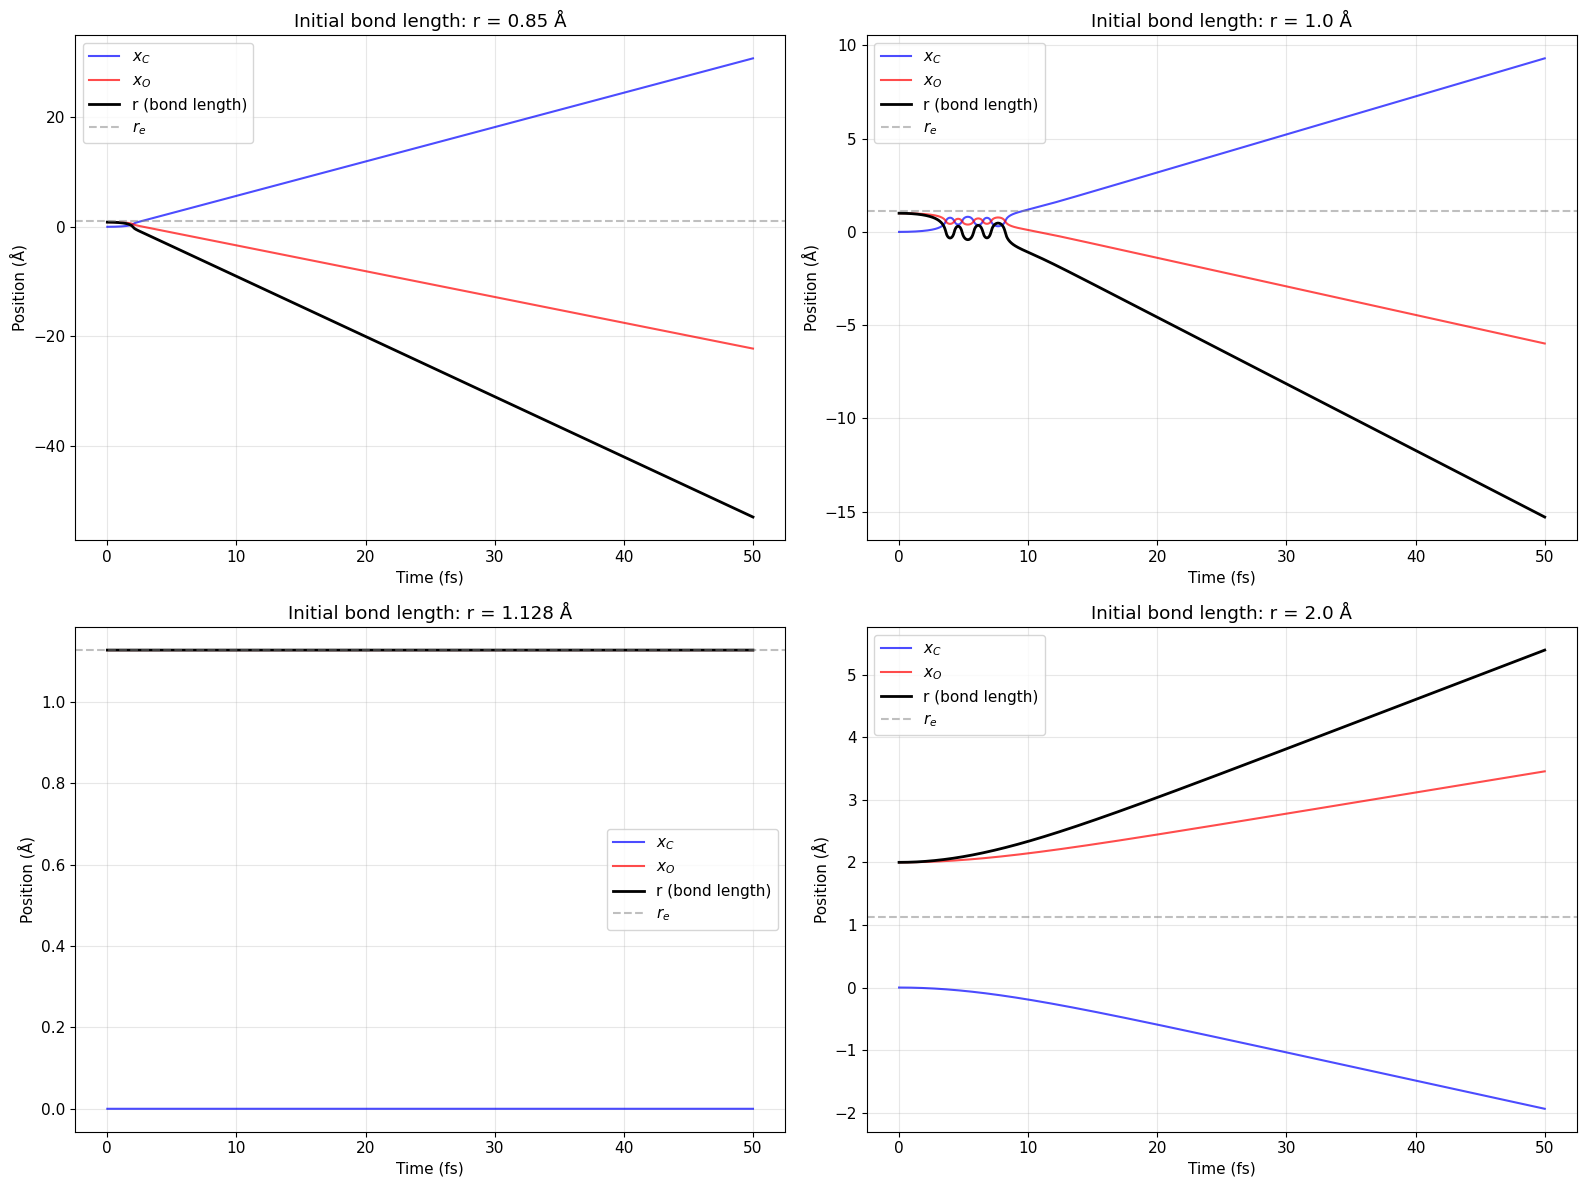



=== Observations and Explanations ===

1. r = 0.85 Å (strongly compressed):
   - The bond is compressed well below equilibrium
   - Strong repulsive forces cause large amplitude vibrations
   - The molecule oscillates around the equilibrium position
   - High initial potential energy is converted to kinetic energy

2. r = 1.00 Å (slightly compressed):
   - The bond is slightly below equilibrium
   - Smaller amplitude vibrations around equilibrium
   - Regular periodic oscillations

3. r = 1.128 Å (equilibrium):
   - Starting exactly at equilibrium with zero velocity
   - The molecule should remain stationary (no force, no velocity)
   - Any small movement is due to numerical errors

4. r = 2.00 Å (highly stretched):
   - The bond is stretched far beyond equilibrium
   - Very high initial potential energy (near dissociation limit)
   - The molecule may dissociate if energy > dissociation energy (11.22 eV)
   - If it doesn't dissociate, it undergoes large amplitude vibrations

General 

In [6]:
# Initial conditions
v0 = np.array([0.0, 0.0])
m = np.array([12.01, 16.00])
dt = 0.01
total_time = 50.0
nsteps = int(total_time / dt)

# Different initial bond lengths
r_initial = [0.85, 1.00, 1.128, 2.00]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, r0 in enumerate(r_initial):
    x0 = np.array([0.0, r0])
    
    md = MD(x0.copy(), v0.copy(), m, dt, CO_morse)
    xC, xO, Ekin, Epot = md.run(nsteps)
    time = np.linspace(0, total_time, nsteps + 1)
    r = xO - xC
    
    ax = axes[idx]
    ax.plot(time, xC, 'b-', label='$x_C$', linewidth=1.5, alpha=0.7)
    ax.plot(time, xO, 'r-', label='$x_O$', linewidth=1.5, alpha=0.7)
    ax.plot(time, r, 'k-', label='r (bond length)', linewidth=2)
    ax.axhline(y=1.128, color='gray', linestyle='--', alpha=0.5, label='$r_e$')
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Position (Å)')
    ax.set_title(f'Initial bond length: r = {r0} Å')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print summary
    print(f"\n--- Initial r = {r0} Å ---")
    print(f"Final bond length: {r[-1]:.3f} Å")
    print(f"Min bond length: {r.min():.3f} Å")
    print(f"Max bond length: {r.max():.3f} Å")
    print(f"Initial energy: {(Ekin[0] + Epot[0]):.3f} eV")
    print(f"Final energy: {(Ekin[-1] + Epot[-1]):.3f} eV")
    
    if r[-1] > 3.0:
        print("→ Molecule DISSOCIATES!")
    else:
        print("→ Molecule remains bound (vibrating)")

plt.tight_layout()
plt.show()

print("\n\n=== Observations and Explanations ===")
print("\n1. r = 0.85 Å (strongly compressed):")
print("   - The bond is compressed well below equilibrium")
print("   - Strong repulsive forces cause large amplitude vibrations")
print("   - The molecule oscillates around the equilibrium position")
print("   - High initial potential energy is converted to kinetic energy")

print("\n2. r = 1.00 Å (slightly compressed):")
print("   - The bond is slightly below equilibrium")
print("   - Smaller amplitude vibrations around equilibrium")
print("   - Regular periodic oscillations")

print("\n3. r = 1.128 Å (equilibrium):")
print("   - Starting exactly at equilibrium with zero velocity")
print("   - The molecule should remain stationary (no force, no velocity)")
print("   - Any small movement is due to numerical errors")

print("\n4. r = 2.00 Å (highly stretched):")
print("   - The bond is stretched far beyond equilibrium")
print("   - Very high initial potential energy (near dissociation limit)")
print("   - The molecule may dissociate if energy > dissociation energy (11.22 eV)")
print("   - If it doesn't dissociate, it undergoes large amplitude vibrations")

print("\nGeneral principle:")
print("The molecule dissociates if the initial potential energy exceeds the dissociation")
print("energy (11.22 eV). Otherwise, it vibrates around the equilibrium position with")
print("amplitude determined by the initial displacement from equilibrium.")

## Problem 2(d): Effect of Initial Velocities

Starting from equilibrium position but with different initial velocities to see how kinetic energy affects the dynamics.


--- Approaching (vC > 0, vO < 0) ---
Initial velocities: vC = 0.05, vO = -0.05 Å/fs
Initial kinetic energy: 3.6291 eV
Initial potential energy: 0.0000 eV
Initial total energy: 3.6291 eV
Bond length range: [-0.428, 14.835] Å
Final total energy: 236.9782 eV
Energy conservation: 2.3335e+02 eV

--- Separating (vC < 0, vO > 0) ---
Initial velocities: vC = -0.05, vO = 0.05 Å/fs
Initial kinetic energy: 3.6291 eV
Initial potential energy: 0.0000 eV
Initial total energy: 3.6291 eV
Bond length range: [1.128, 10.933] Å
Final total energy: 26.0693 eV
Energy conservation: 2.2440e+01 eV

--- Fast approaching ---
Initial velocities: vC = 0.1, vO = -0.1 Å/fs
Initial kinetic energy: 14.5163 eV
Initial potential energy: 0.0000 eV
Initial total energy: 14.5163 eV
Bond length range: [-0.437, 36.739] Å
Final total energy: 243.8202 eV
Energy conservation: 2.2930e+02 eV

--- Fast separating ---
Initial velocities: vC = -0.1, vO = 0.1 Å/fs
Initial kinetic energy: 14.5163 eV
Initial potential energy: 0.0000 e

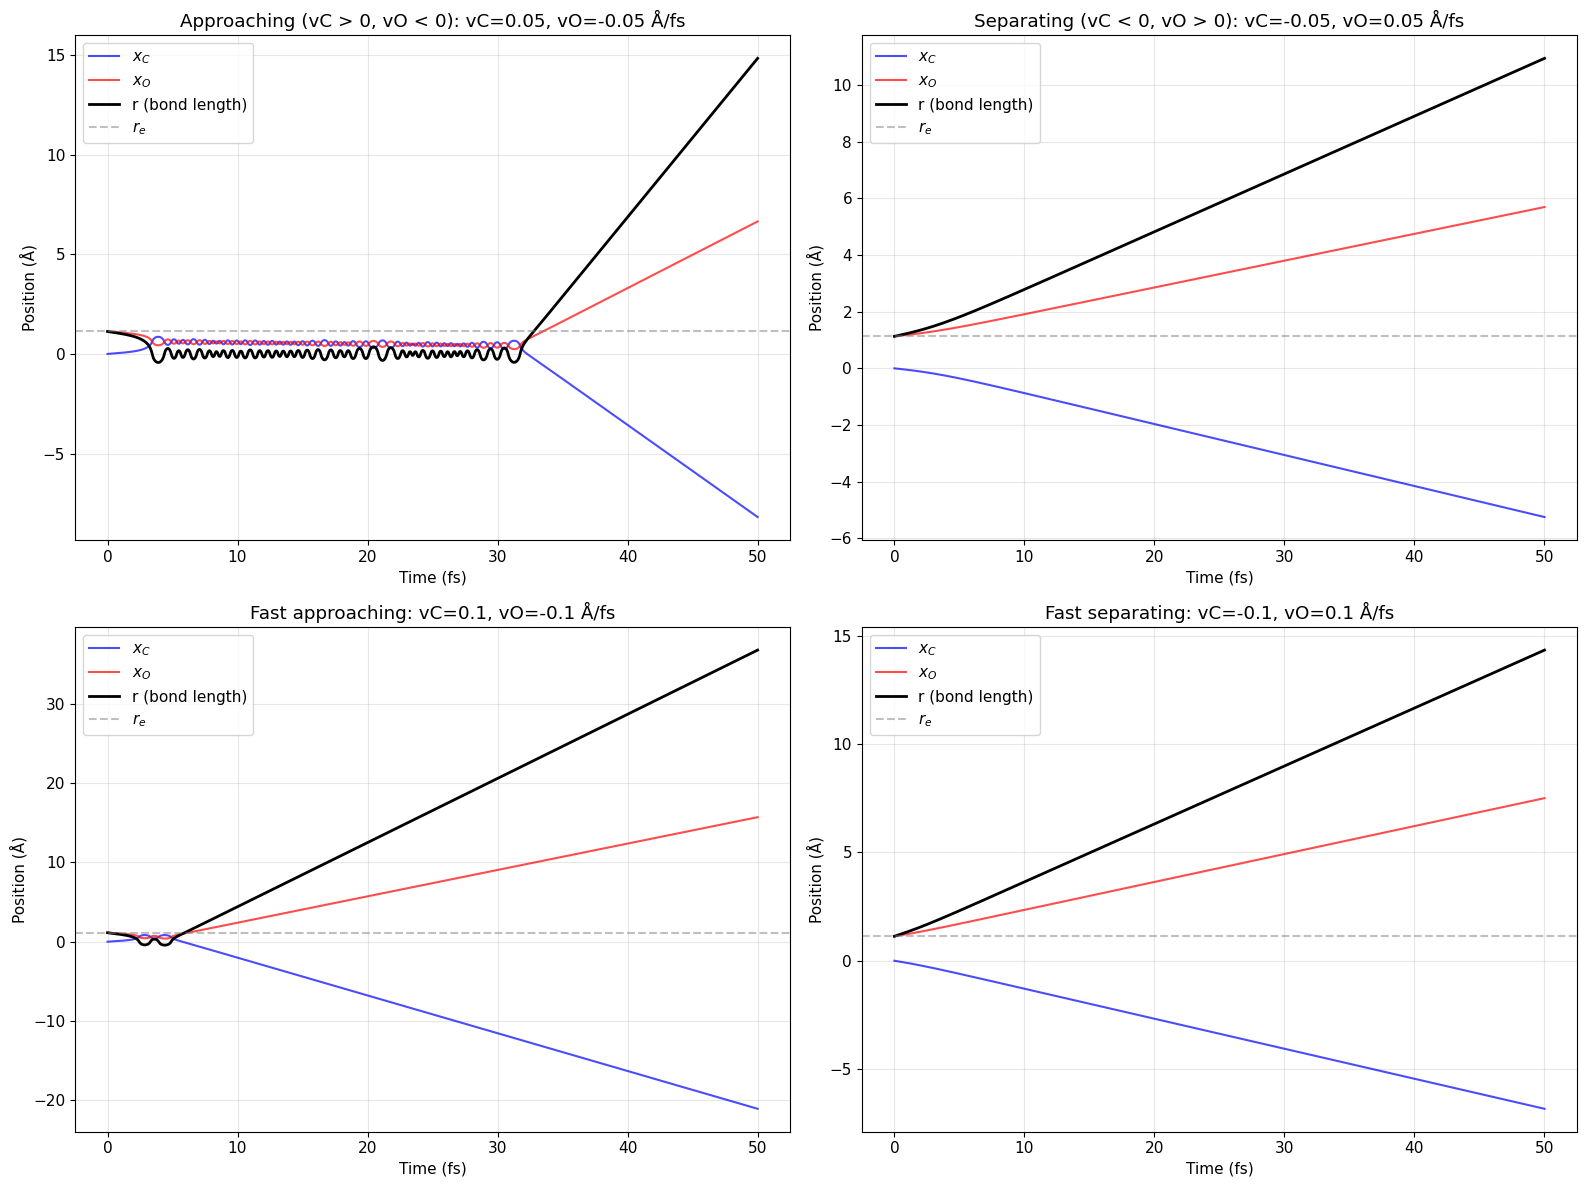



=== Explanation of Results ===

All simulations start at the equilibrium position (r = 1.128 Å) but with different
initial velocities. The behavior depends on whether the atoms are initially moving
toward each other (approaching) or away from each other (separating).

1. Approaching (vC > 0, vO < 0):
   - Carbon moves right (+x), oxygen moves left (-x)
   - Bond initially compresses (r decreases below equilibrium)
   - Repulsive forces reverse the motion, causing vibrations
   - Initial kinetic energy is converted to potential energy as bond compresses

2. Separating (vC < 0, vO > 0):
   - Carbon moves left (-x), oxygen moves right (+x)
   - Bond initially stretches (r increases above equilibrium)
   - Attractive forces pull atoms back, causing vibrations
   - Initial kinetic energy is converted to potential energy as bond stretches

3. Effect of velocity magnitude:
   - Higher initial velocities → larger amplitude vibrations
   - Higher initial velocities → higher total energy
   - 

In [8]:
# Initial conditions
re = 1.128  # Equilibrium bond length
m = np.array([12.01, 16.00])
dt = 0.01
total_time = 50.0
nsteps = int(total_time / dt)

# Different initial velocity combinations
velocity_cases = [
    ([0.05, -0.05], 'Approaching (vC > 0, vO < 0)'),
    ([-0.05, 0.05], 'Separating (vC < 0, vO > 0)'),
    ([0.1, -0.1], 'Fast approaching'),
    ([-0.1, 0.1], 'Fast separating')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (v_init, label) in enumerate(velocity_cases):
    x0 = np.array([0.0, re])
    v0 = np.array(v_init)
    
    md = MD(x0.copy(), v0.copy(), m, dt, CO_morse)
    xC, xO, Ekin, Epot = md.run(nsteps)
    time = np.linspace(0, total_time, nsteps + 1)
    r = xO - xC
    
    ax = axes[idx]
    ax.plot(time, xC, 'b-', label='$x_C$', linewidth=1.5, alpha=0.7)
    ax.plot(time, xO, 'r-', label='$x_O$', linewidth=1.5, alpha=0.7)
    ax.plot(time, r, 'k-', label='r (bond length)', linewidth=2)
    ax.axhline(y=re, color='gray', linestyle='--', alpha=0.5, label='$r_e$')
    ax.set_xlabel('Time (fs)')
    ax.set_ylabel('Position (Å)')
    ax.set_title(f'{label}: vC={v_init[0]}, vO={v_init[1]} Å/fs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Print summary
    print(f"\n--- {label} ---")
    print(f"Initial velocities: vC = {v_init[0]}, vO = {v_init[1]} Å/fs")
    print(f"Initial kinetic energy: {Ekin[0]:.4f} eV")
    print(f"Initial potential energy: {Epot[0]:.4f} eV")
    print(f"Initial total energy: {(Ekin[0] + Epot[0]):.4f} eV")
    print(f"Bond length range: [{r.min():.3f}, {r.max():.3f}] Å")
    print(f"Final total energy: {(Ekin[-1] + Epot[-1]):.4f} eV")
    print(f"Energy conservation: {abs((Ekin[-1] + Epot[-1]) - (Ekin[0] + Epot[0])):.4e} eV")

plt.tight_layout()
plt.show()

print("\n\n=== Explanation of Results ===")
print("\nAll simulations start at the equilibrium position (r = 1.128 Å) but with different")
print("initial velocities. The behavior depends on whether the atoms are initially moving")
print("toward each other (approaching) or away from each other (separating).")

print("\n1. Approaching (vC > 0, vO < 0):")
print("   - Carbon moves right (+x), oxygen moves left (-x)")
print("   - Bond initially compresses (r decreases below equilibrium)")
print("   - Repulsive forces reverse the motion, causing vibrations")
print("   - Initial kinetic energy is converted to potential energy as bond compresses")

print("\n2. Separating (vC < 0, vO > 0):")
print("   - Carbon moves left (-x), oxygen moves right (+x)")
print("   - Bond initially stretches (r increases above equilibrium)")
print("   - Attractive forces pull atoms back, causing vibrations")
print("   - Initial kinetic energy is converted to potential energy as bond stretches")

print("\n3. Effect of velocity magnitude:")
print("   - Higher initial velocities → larger amplitude vibrations")
print("   - Higher initial velocities → higher total energy")
print("   - If kinetic energy is high enough, molecule can dissociate")

print("\n4. Center of mass motion:")
print("   - The center of mass position: x_cm = (mC*xC + mO*xO)/(mC + mO)")
print("   - With equal and opposite velocities, center of mass velocity is not zero")
print("   - The molecule vibrates while also translating through space")

print("\n Starting from equilibrium with non-zero velocities results in")
print("vibrations with amplitude determined by the initial kinetic energy. The direction")
print("of initial velocities determines whether the bond first compresses or stretches.")